# Flight delay prediction: pipeline walkthrough

2015 US DOT on-time data, 5,704,000 curated flights, PySpark MLlib.

1. A one-column check on the wheels-off model
2. The three tasks
3. The data: correlation table and the keep/drop decisions
4. The pipeline, and what one flight's feature vector looks like
5. The final features and their distributions
6. Model metrics against baselines

Rebuild with `python scripts/build_rework_notebook.py` (after `source ./env.sh`).

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, REPO)
from model_explain import _style, BLUE, INK, INK_2
import mllib_pipeline as mp
%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 80)
plt.rcParams["figure.dpi"] = 110
ORANGE = "#B4532A"

cols = ["MONTH", "DAY", "DAY_OF_WEEK", "IS_WEEKEND", "DEP_HOUR", "AIRLINE", "FLIGHT_NUMBER",
        "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "SCHED_DEP_MIN", "SCHED_ARR_MIN",
        "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON", "DISTANCE", "SCHEDULED_TIME",
        "DEPARTURE_DELAY", "TAXI_OUT", "label_delay", "label_severe"]
d = ds.dataset(os.path.join(REPO, "data", "parquet", "flights_curated")).to_table(columns=cols).to_pandas()

# The project's split, by whole days: in every month 6 validation days and 6 holdout days
# (seed 42). Validation scores every choice; the holdout is kept for the final numbers.
day = d["MONTH"] * 100 + d["DAY"]
d["part"] = np.where(day.isin(mp.validation_days()), "validation",
                     np.where(day.isin(mp.holdout_days()), "holdout", "train"))
d["is_train"], d["is_val"] = d["part"] == "train", d["part"] == "validation"
print(d.groupby("part").agg(flights=("MONTH", "size"),
                            days=("DAY", lambda s: (d.loc[s.index, "MONTH"] * 100 + s).nunique())))

            flights  days
part                     
holdout     1113271    72
train       3468588   221
validation  1122141    72


## 1. A one-column check on the wheels-off model

The first version of the project predicted the arrival delay at **wheels-off**, when the
aircraft has already left the gate and taken off. It scored R² 0.93 (regression) and
AUC 0.98 (flights more than 30 minutes late). Scores that high raise the question of a leak.

The check: keep **one column only, `DEPARTURE_DELAY`**, fit an ordinary least-squares line
on the training days and score it on the validation days. No other feature, no model tuning.

In [2]:
tr, te = d[d.is_train], d[d.is_val]
x_tr, y_tr = tr["DEPARTURE_DELAY"].to_numpy(float), tr["label_delay"].to_numpy(float)
x_te, y_te = te["DEPARTURE_DELAY"].to_numpy(float), te["label_delay"].to_numpy(float)
slope, intercept = np.polyfit(x_tr, y_tr, 1)
pred = intercept + slope * x_te
r2 = 1 - ((y_te - pred) ** 2).sum() / ((y_te - y_te.mean()) ** 2).sum()
mae = np.abs(y_te - pred).mean()

from sklearn.metrics import roc_auc_score, average_precision_score
auc = roc_auc_score(te["label_severe"], x_te)          # the departure delay itself as the score
auc_pr = average_precision_score(te["label_severe"], x_te)

old = json.load(open(os.path.join(REPO, "docs", "benchmarks", "tournament_results.json")))
check = pd.DataFrame([
    ["arrival delay = a + b × DEPARTURE_DELAY", "R²", r2, old["linear_regression__nopca"]["r2"]],
    ["", "MAE (min)", mae, old["linear_regression__nopca"]["mae"]],
    ["rank flights by DEPARTURE_DELAY", "AUC", auc, old["gbt_classifier__nopca"]["areaUnderROC"]],
    ["", "AUC-PR", auc_pr, old["gbt_classifier__nopca"]["areaUnderPR"]],
], columns=["one column only", "metric", "one column",
            "old wheels-off model (all features, row-level split)"])
print(f"fitted line: arrival delay = {intercept:.2f} + {slope:.3f} × DEPARTURE_DELAY")
display(check.round(3))

fitted line: arrival delay = -5.05 + 1.004 × DEPARTURE_DELAY


,one column only,metric,one column,"old wheels-off model (all features, row-level split)"
0,arrival delay = a + b × DEPARTURE_DELAY,R²,0.900,0.929
1,,MAE (min),9.237,7.194
2,rank flights by DEPARTURE_DELAY,AUC,0.960,0.984
3,,AUC-PR,0.904,0.943


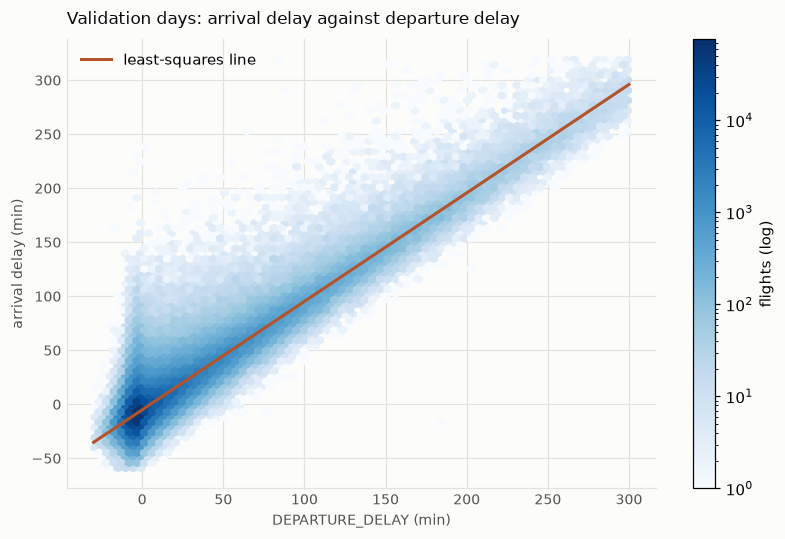

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5))
m = (x_te > -30) & (x_te < 300) & (y_te > -60) & (y_te < 320)
hb = ax.hexbin(x_te[m], y_te[m], gridsize=70, bins="log", cmap="Blues", mincnt=1)
xs = np.array([-30, 300])
ax.plot(xs, intercept + slope * xs, color=ORANGE, linewidth=2, label="least-squares line")
ax.legend(frameon=False, loc="upper left")
_style(ax, "DEPARTURE_DELAY (min)", "arrival delay (min)", "Validation days: arrival delay against departure delay")
fig.colorbar(hb, ax=ax, label="flights (log)")
fig.tight_layout(); plt.show()

**Reading.** One straight line on `DEPARTURE_DELAY` already reaches almost all of the old
model's score (table above); the other twenty-odd columns added only a few hundredths of R².
Nothing leaks from the future: the label, the arrival times and the five delay-attribution
columns (which sum to the arrival delay) are removed at ingestion (`flight_schema.LEAKY_COLUMNS`),
and every fitted stage learns on the training days only. The score is high because at
wheels-off the departure delay is already known, and the arrival delay is roughly the
departure delay plus a small correction. The task is legitimate but easy, and it says little
about what the model learned. That is why the project was split into three tasks.

## 2. The three tasks

| Task | Predicted when | Target | Models |
|---|---|---|---|
| **A** regression | at the gate, once the aircraft for this flight has arrived, before pushback | `label_delay`: minutes late at arrival | LinearRegression, GLM (Gaussian, identity link), RandomForest, GBT |
| **C** classification | same moment as A | `label_severe`: 1 if more than 30 min late, else 0 | LinearSVC, RandomForest, GBT |
| **B** regression | at wheels-off | `label_gain` = `label_delay` − `DEPARTURE_DELAY`: minutes made up (negative) or lost after pushback | LinearRegression, GLM, RandomForest, GBT |

- **The moment A and C predict at** is when the aircraft for this flight has landed from its
  previous leg, so that leg's arrival delay (`prev_arr_delay`) is known. For about 6% of the
  flights that have a previous leg (about 4.5% of all flights) the aircraft lands after this
  flight's scheduled departure; the prediction then happens at that later moment. A prediction made earlier (the day before, or two hours
  ahead) must use the schedule alone: on task C that drops the GBT AUC from about 0.82 to
  about 0.68 (1% ablation). In operation the inbound would be known through its ETA, which
  is noisier than the actual arrival used here.
- **A and C** use nothing observed at or after pushback: `DEPARTURE_DELAY`, `TAXI_OUT`,
  `WHEELS_OFF` are blocked in code (`mllib_pipeline.PRE_DEPARTURE_FORBIDDEN`, asserted when the
  pipeline is built). No feature is computed from the label, at any horizon.
- **B** keeps the wheels-off moment but removes the part that is already known: the model
  predicts only the gain, and the arrival delay is recovered as
  `DEPARTURE_DELAY + predicted gain`.
- Split **by whole days**, in every month: 6 **validation** days and 6 **holdout** days
  (72 + 72 of 365), the other 221 days for training. Flights on one day share weather,
  congestion and aircraft rotations, so a row-level split would put near-copies of each
  evaluated day into training.
- **Validation** scores every choice: features, caps, hyperparameters, the winning model.
  Cross-validation folds are whole days too. The **holdout** days are never looked at until
  the final run, which trains on train + validation and is scored once on them.

## 3. The data

| Step | Flights |
|---|---:|
| Raw 2015 file | 5,819,079 |
| cancelled (no arrival, no label) | −89,884 |
| diverted (no arrival at the scheduled airport) | −15,187 |
| airport without coordinates | −10,008 |
| **Curated** | **5,704,000** |

October 2015 uses numeric DOT airport ids instead of IATA codes; they are mapped back
(`data/dot_to_iata.csv`, 99.8% of October recovered) so October is not silently lost in the
airport join.

### 3.1 Candidate features

Every column a model could plausibly use, computed as the pipeline computes it. The
aircraft-rotation columns look at the previous leg flown by the same aircraft
(`TAIL_NUMBER`) on the same day, and count only when that leg landed where this one departs.

In [4]:
d = d.sort_values(["TAIL_NUMBER", "MONTH", "DAY", "SCHED_DEP_MIN", "FLIGHT_NUMBER"]).reset_index(drop=True)
g = d.groupby(["TAIL_NUMBER", "MONTH", "DAY"], sort=False)
d["leg_of_day"] = g.cumcount() + 1.0
linked = g["DESTINATION_AIRPORT"].shift() == d["ORIGIN_AIRPORT"]
d["has_prev"] = linked.astype(float)
d["turn_slack"] = np.where(linked, d["SCHED_DEP_MIN"] - g["SCHED_ARR_MIN"].shift(), np.nan)
d["prev_dep_delay"] = np.where(linked, g["DEPARTURE_DELAY"].shift(), np.nan)
d["prev_arr_delay"] = np.where(linked, g["label_delay"].shift(), np.nan)
d["prev_air_gain"] = d["prev_arr_delay"] - d["prev_dep_delay"]
d["inbound_overrun"] = np.maximum(d["prev_arr_delay"] - d["turn_slack"], 0)

d["hour_sin"] = np.sin(2 * np.pi * d["SCHED_DEP_MIN"] / 1440)
d["hour_cos"] = np.cos(2 * np.pi * d["SCHED_DEP_MIN"] / 1440)
d["log_distance"] = np.log1p(d["DISTANCE"])
d["sched_mph"] = d["DISTANCE"] / (d["SCHEDULED_TIME"] / 60)
# The usual block time for a distance, a least-squares line on the training days, and how
# far this flight's schedule sits above it (the pipeline's SchedulePadding stage).
pad_b, pad_a = np.polyfit(d.loc[d.is_train, "DISTANCE"], d.loc[d.is_train, "SCHEDULED_TIME"], 1)
d["sched_padding"] = d["SCHEDULED_TIME"] - (pad_a + pad_b * d["DISTANCE"])
print(f"usual block time = {pad_a:.1f} + {pad_b:.4f} x DISTANCE minutes")
lat1, lon1, lat2, lon2 = (np.radians(d[c]) for c in ["ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON"])
a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
d["gc_distance"] = 2 * 3958.8 * np.arcsin(np.sqrt(a))
d["ROUTE_DETOUR"] = d["DISTANCE"] / d["gc_distance"].where(d["gc_distance"] > 0)
d["label_gain"] = d["label_delay"] - d["DEPARTURE_DELAY"]

# Airport busyness from the training days only: log of the airport's share of flights, per million.
n_tr = d.is_train.sum()
for src, dst in [("ORIGIN_AIRPORT", "freq_origin"), ("DESTINATION_AIRPORT", "freq_dest")]:
    share = d.loc[d.is_train, src].value_counts() / n_tr * 1e6
    d[dst] = np.log1p(d[src].map(share).fillna(0.0))

# Scheduled arrivals at the destination in that hour, counted from the published schedule
# (cancelled flights included, so a stormy day does not look quiet).
raw = ds.dataset(os.path.join(REPO, "data", "parquet", "flights_raw"), partitioning="hive").to_table(
    columns=["MONTH", "DAY", "DESTINATION_AIRPORT", "SCHEDULED_ARRIVAL"]).to_pandas()
code_map = pd.read_csv(os.path.join(REPO, "data", "dot_to_iata.csv"), dtype=str)
raw["DESTINATION_AIRPORT"] = raw["DESTINATION_AIRPORT"].replace(dict(zip(code_map["dot_code"], code_map["iata_code"])))
raw["MONTH"] = raw["MONTH"].astype(int)
raw["_h"] = (pd.to_numeric(raw["SCHEDULED_ARRIVAL"]) // 100 % 24).astype(int)
cnt = raw.groupby(["DESTINATION_AIRPORT", "MONTH", "DAY", "_h"]).size().rename("_n").reset_index()
d["_h"] = (d["SCHED_ARR_MIN"] // 60).astype(int)
d = d.merge(cnt, on=["DESTINATION_AIRPORT", "MONTH", "DAY", "_h"], how="left")
d["sched_dest_hour"] = np.log1p(d["_n"])
d = d.drop(columns=["_h", "_n"])
del raw, cnt
print(f"{len(d):,} flights, {d.shape[1]} columns")

usual block time = 41.5 + 0.1218 x DISTANCE minutes


5,704,000 flights, 43 columns


### 3.2 Correlation table

Pearson correlation of every candidate with the three targets, on the training days, plus the
candidate it duplicates most. Correlation measures a straight line only, so it is the first
filter, not the verdict: every drop was confirmed by an ablation test (one change at a time,
all seven models, same sample and validation days; a difference under 0.005 that does not point the
same way across models counts as a tie, and the simpler set wins). The tests are in
`experiments/feature_ablation.xlsx`.

In [5]:
CAND = ["SCHED_DEP_MIN", "SCHED_ARR_MIN", "hour_sin", "hour_cos", "MONTH", "DAY", "DAY_OF_WEEK", "IS_WEEKEND",
        "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON", "DISTANCE", "log_distance", "gc_distance",
        "ROUTE_DETOUR", "SCHEDULED_TIME", "sched_mph", "sched_padding", "freq_origin", "freq_dest",
        "sched_dest_hour",
        "leg_of_day", "has_prev", "turn_slack", "prev_dep_delay", "prev_arr_delay", "prev_air_gain",
        "inbound_overrun", "TAXI_OUT", "DEPARTURE_DELAY"]
TARGETS = ["label_delay", "label_severe", "label_gain"]
USED = {  # feature: (tasks that use it, reason)
    "SCHED_ARR_MIN": ("A B C", "the trees read the time of day from it; removing it lowers tree AUC"),
    "hour_sin": ("A B C", "hour on a circle (23:00 next to 00:00); replaced 24 one-hot slots, LinearSVC better on 3 seeds"),
    "hour_cos": ("A B C", "pair of hour_sin"),
    "SCHED_DEP_MIN": ("dropped", "enters through hour_sin and hour_cos"),
    "MONTH": ("A B C", "one-hot; removing it hurts all 7 models"),
    "DAY": ("dropped", "|r| < 0.01 with every target, no mechanism"),
    "DAY_OF_WEEK": ("dropped", "tie on 3 seeds, as one-hot or as sin/cos"),
    "IS_WEEKEND": ("dropped", "a function of DAY_OF_WEEK"),
    "ORIGIN_LAT": ("A B C", "the trees locate the airport; removing the 4 coordinates costs RF 0.009 AUC"),
    "ORIGIN_LON": ("A B C", "as ORIGIN_LAT"), "DEST_LAT": ("A B C", "as ORIGIN_LAT"), "DEST_LON": ("A B C", "as ORIGIN_LAT"),
    "DISTANCE": ("B", "route length; no measurable effect in A, C"),
    "log_distance": ("dropped", "duplicates DISTANCE; in A, C removing it changes nothing measurable"),
    "gc_distance": ("dropped", "duplicates DISTANCE; needed a slow Python UDF"),
    "ROUTE_DETOUR": ("dropped", "|r| < 0.01 with every target"),
    "SCHEDULED_TIME": ("dropped", "r 0.98 with DISTANCE; its useful part enters B as sched_padding"),
    "sched_mph": ("dropped", "mixes padding and distance; sched_padding separates them"),
    "sched_padding": ("B", "minutes scheduled beyond the usual block time for the distance; "
                           "the gain falls as it grows"),
    "freq_origin": ("dropped", "tie; the coordinates already identify the airport"),
    "freq_dest": ("dropped", "tie; the coordinates already identify the airport"),
    "sched_dest_hour": ("B", "busy destination hour means holding; LinearRegression +0.025 R²; tie in A, C"),
    "leg_of_day": ("A C", "later legs inherit the day's delays"),
    "has_prev": ("A C", "marks the first leg, where the prev_* columns are imputed"),
    "turn_slack": ("A C", "scheduled ground time before this departure"),
    "prev_dep_delay": ("dropped", "r 0.93 with prev_arr_delay, which is known later and supersedes it"),
    "prev_arr_delay": ("A C", "strongest signal before departure; capped at 300 (A) and 60 (C)"),
    "prev_air_gain": ("dropped", "removing it changes nothing measurable"),
    "inbound_overrun": ("A C", "minutes the inbound lands past this flight's ground time; capped like prev_arr_delay"),
    "TAXI_OUT": ("B", "strongest signal for the gain; known only after pushback, so blocked in A, C"),
    "DEPARTURE_DELAY": ("dropped", "blocked in A, C; in B the gain is flat in it (section 5)"),
}
trn = d.loc[d.is_train, CAND + TARGETS]
corr = trn.corr()
tab = corr.loc[CAND, TARGETS].copy()
others = corr.loc[CAND, CAND].where(~np.eye(len(CAND), dtype=bool))
tab["closest other feature"] = others.abs().idxmax(axis=1)
tab["its r"] = [others.loc[c, tab.loc[c, "closest other feature"]] for c in CAND]
tab["used in"] = [USED[c][0] for c in CAND]
tab["reason"] = [USED[c][1] for c in CAND]
tab = tab.rename(columns={"label_delay": "r delay", "label_severe": "r severe", "label_gain": "r gain"})
(tab.style.format({"r delay": "{:+.3f}", "r severe": "{:+.3f}", "r gain": "{:+.3f}", "its r": "{:+.2f}"})
    .apply(lambda s: ["color: #9A9A9A" if v == "dropped" else "font-weight: bold" for v in s], subset=["used in"])
    .set_properties(subset=["reason"], **{"text-align": "left"}))

,r delay,r severe,r gain,closest other feature,its r,used in,reason
SCHED_DEP_MIN,+0.099,+0.116,-0.011,hour_sin,-0.90,dropped,enters through hour_sin and hour_cos
SCHED_ARR_MIN,+0.088,+0.101,-0.010,hour_sin,-0.77,A B C,the trees read the time of day from it; removing it lowers tree AUC
hour_sin,-0.105,-0.119,+0.005,SCHED_DEP_MIN,-0.90,A B C,"hour on a circle (23:00 next to 00:00); replaced 24 one-hot slots, LinearSVC better on 3 seeds"
hour_cos,+0.037,+0.052,-0.014,SCHED_DEP_MIN,+0.53,A B C,pair of hour_sin
MONTH,-0.043,-0.039,-0.048,prev_air_gain,-0.05,A B C,one-hot; removing it hurts all 7 models
DAY,+0.016,+0.012,+0.007,IS_WEEKEND,-0.05,dropped,"|r| < 0.01 with every target, no mechanism"
DAY_OF_WEEK,-0.013,-0.010,-0.019,IS_WEEKEND,+0.77,dropped,"tie on 3 seeds, as one-hot or as sin/cos"
IS_WEEKEND,-0.022,-0.016,-0.034,DAY_OF_WEEK,+0.77,dropped,a function of DAY_OF_WEEK
ORIGIN_LAT,-0.011,+0.003,-0.014,DEST_LAT,+0.28,A B C,the trees locate the airport; removing the 4 coordinates costs RF 0.009 AUC
ORIGIN_LON,+0.002,+0.029,-0.076,DEST_LON,+0.59,A B C,as ORIGIN_LAT


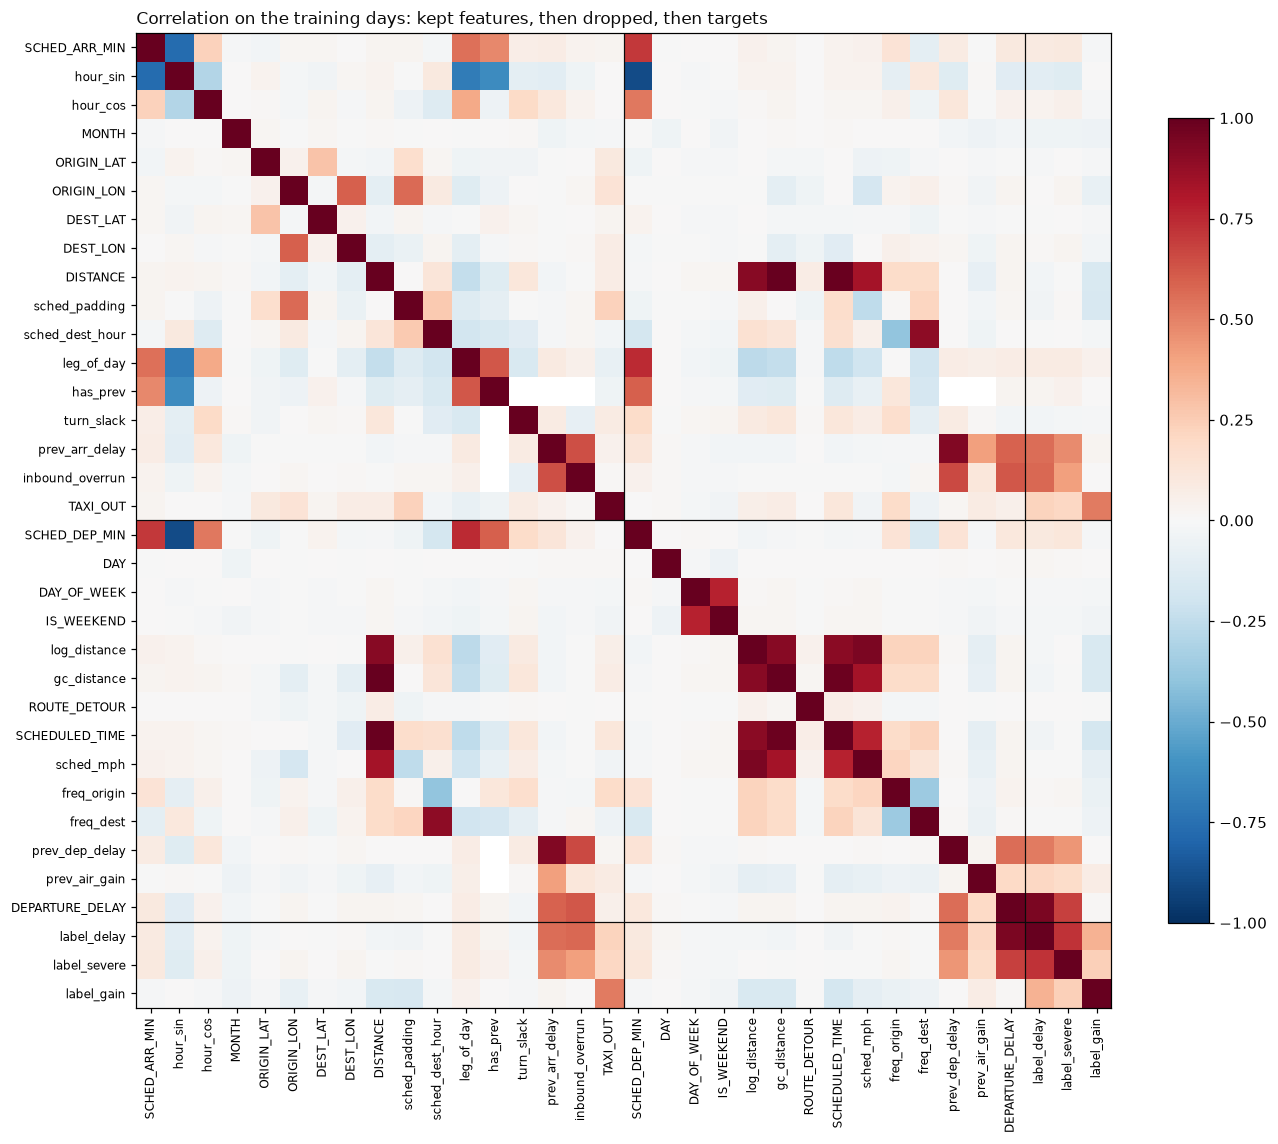

In [6]:
order = [c for c in CAND if USED[c][0] != "dropped"] + [c for c in CAND if USED[c][0] == "dropped"]
m = corr.loc[order + TARGETS, order + TARGETS]
fig, ax = plt.subplots(figsize=(12, 10.5))
im = ax.imshow(m, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(m))); ax.set_xticklabels(m.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index, fontsize=8)
n_kept = len([c for c in CAND if USED[c][0] != "dropped"])
for k in (n_kept - 0.5, len(order) - 0.5):
    ax.axhline(k, color=INK, linewidth=0.8); ax.axvline(k, color=INK, linewidth=0.8)
ax.set_title("Correlation on the training days: kept features, then dropped, then targets",
             loc="left", fontsize=11, color=INK)
fig.colorbar(im, ax=ax, fraction=0.035)
fig.tight_layout(); plt.show()

What the map shows:

- `DISTANCE`, `log_distance`, `gc_distance` and `SCHEDULED_TIME` form one block (r 0.94 to 1.00):
  one of them is enough for tasks A and C. Task B's target depends on the difference between
  scheduled time and distance (the schedule padding), so B keeps `DISTANCE` plus
  `sched_padding`, which is almost uncorrelated with it.
- `prev_dep_delay` and `prev_arr_delay` (r 0.92) say the same thing; the arrival is known later
  and supersedes the departure.
- `freq_dest` and `sched_dest_hour` (r 0.89) both measure how busy the destination is.
- Before departure, only the inbound columns reach |r| 0.4 to 0.6 with the targets; everything
  in the schedule stays near 0. At wheels-off, `DEPARTURE_DELAY` has r 0.94 with the delay but
  almost none with the gain, while `TAXI_OUT` has r 0.52 with the gain.
- The blank cells: `has_prev` is 1 wherever the `prev_*` columns exist, so the correlation between
  them is undefined.

### 3.3 The categorical columns

`AIRLINE` and `MONTH` enter as one-hot vectors, so a correlation coefficient does not describe
them. The share of flights more than 30 minutes late by category shows whether they carry
signal: a wide spread between categories means the column is worth a one-hot.

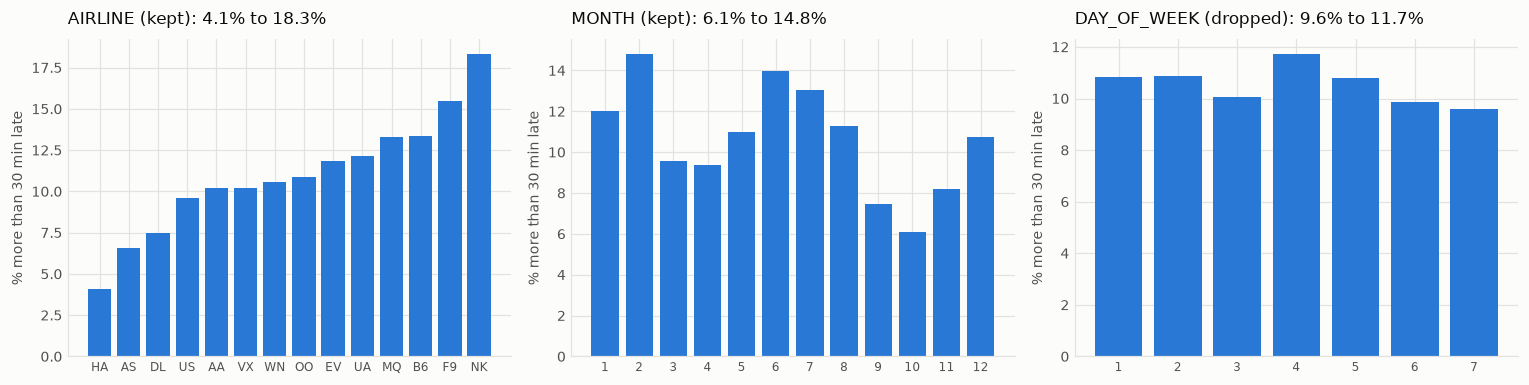

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, col, title in zip(axes, ["AIRLINE", "MONTH", "DAY_OF_WEEK"],
                          ["AIRLINE (kept)", "MONTH (kept)", "DAY_OF_WEEK (dropped)"]):
    rate = d.loc[d.is_train].groupby(col)["label_severe"].mean()
    if col == "AIRLINE":
        rate = rate.sort_values()
    ax.bar(rate.index.astype(str), rate.values * 100, color=BLUE)
    _style(ax, "", "% more than 30 min late", f"{title}: {rate.min():.1%} to {rate.max():.1%}")
    ax.tick_params(axis="x", labelsize=8)
fig.tight_layout(); plt.show()

## 4. The pipeline

Before the pipeline, two lookups are joined by key: the aircraft's previous leg (rotation
columns) and, for task B, the destination's scheduled arrivals that hour. They look at other
flights, so they cannot be pipeline stages (a stage sees one row, and a streaming micro-batch
does not hold the rest of the day).

The stages below are built by the project's own code (`mllib_pipeline.build_feature_stages`)
for each task's feature set; the estimator is appended after the last stage. Stages marked
*fitted* learn their parameters from the training days only.

In [8]:
os.environ["PYSPARK_SUBMIT_ARGS"] = "--driver-memory 2g pyspark-shell"
from spark_session import build_spark
spark = build_spark("walkthrough", cores="2", driver_memory="2g", shuffle_partitions=4)
spark.sparkContext.setLogLevel("ERROR")

WHAT = {
    "SQLTransformer": "computed column (no fitting)",
    "SignedLog1pTransformer": "log(1 + x), keeps the sign",
    "Imputer": "fills missing values with the training median",
    "StringIndexer": "AIRLINE text to an index",
    "OneHotEncoder": "index to a one-hot vector",
    "MaterializeCache": "caches the frame for the fits that follow",
    "VectorAssembler": "joins every column into one vector",
    "StandardScaler": "divides each slot by its training std (no centring, keeps the vector sparse)",
    "VarianceThresholdSelector": "drops slots that are constant in training",
}
FITTED = {"Imputer", "StringIndexer", "OneHotEncoder", "StandardScaler", "VarianceThresholdSelector"}

def describe(stage):
    name = type(stage).__name__
    if name == "SQLTransformer":
        s = stage.getStatement()
        body = s.split("SELECT *,", 1)[1].split("FROM __THIS__")[0].strip()
        outs = [p.strip().split(" AS ")[-1] for p in body.split(", ") if " AS " in p]
        io = "→ " + ", ".join(outs)
    else:
        ins = stage.getInputCols() if stage.hasParam("inputCols") and stage.isSet("inputCols") else (
            [stage.getInputCol()] if stage.hasParam("inputCol") and stage.isSet("inputCol") else
            [stage.getFeaturesCol()] if stage.hasParam("featuresCol") else [])
        outs = stage.getOutputCols() if stage.hasParam("outputCols") and stage.isSet("outputCols") else (
            [stage.getOutputCol()] if stage.hasParam("outputCol") else [])
        io = ((", ".join(ins) if len(ins) <= 4 else f"{len(ins)} columns") + " → " + ", ".join(outs)
              if ins or outs else "(whole frame)")
    return name, WHAT.get(name, ""), "fitted" if name in FITTED else "", io

SETS = {"A": "predeparture_a", "C": "predeparture_c", "B": "wheelsoff_gain_pad"}
tables = {}
for task, fs in SETS.items():
    spec = mp.FEATURE_SETS[fs]
    stages, _ = mp.build_feature_stages(mp.reg_label_for(spec), use_pca=False, pca_k=0, feature_set=fs)
    rows = [describe(s) for s in stages if not (type(s).__name__ == "SQLTransformer"
                                              and "features_selected AS features" in s.getStatement())]
    tables[task] = pd.DataFrame(rows, columns=["stage", "what it does", "learns", "columns"],
                                index=range(1, len(rows) + 1))
for task in ["A", "C", "B"]:
    display(Markdown(f"**Task {task}** (`{SETS[task]}`), no-PCA arm, then the estimator"))
    display(tables[task].style.set_properties(**{"text-align": "left"}))

**Task A** (`predeparture_a`), no-PCA arm, then the estimator

,stage,what it does,learns,columns
1,SQLTransformer,computed column (no fitting),,→ prev_arr_delay_cap300
2,SQLTransformer,computed column (no fitting),,→ inbound_overrun_cap300
3,Imputer,fills missing values with the training median,fitted,"10 columns → SCHED_ARR_MIN, ORIGIN_LAT, ORIGIN_LON, DEST_LAT, DEST_LON, leg_of_day, has_prev, turn_slack, prev_arr_delay_cap300, inbound_overrun_cap300"
4,SQLTransformer,computed column (no fitting),,"→ hour_sin, hour_cos"
5,StringIndexer,AIRLINE text to an index,fitted,AIRLINE → airline_idx
6,OneHotEncoder,index to a one-hot vector,fitted,"airline_idx, MONTH → airline_idx_ohe, MONTH_ohe"
7,MaterializeCache,caches the frame for the fits that follow,,(whole frame)
8,VectorAssembler,joins every column into one vector,,14 columns → features_raw
9,StandardScaler,"divides each slot by its training std (no centring, keeps the vector sparse)",fitted,features_raw → features_scaled
10,VarianceThresholdSelector,drops slots that are constant in training,fitted,features_scaled → features_selected


**Task C** (`predeparture_c`), no-PCA arm, then the estimator

,stage,what it does,learns,columns
1,SQLTransformer,computed column (no fitting),,→ prev_arr_delay_cap60
2,SQLTransformer,computed column (no fitting),,→ inbound_overrun_cap60
3,Imputer,fills missing values with the training median,fitted,"10 columns → SCHED_ARR_MIN, ORIGIN_LAT, ORIGIN_LON, DEST_LAT, DEST_LON, leg_of_day, has_prev, turn_slack, prev_arr_delay_cap60, inbound_overrun_cap60"
4,SQLTransformer,computed column (no fitting),,"→ hour_sin, hour_cos"
5,StringIndexer,AIRLINE text to an index,fitted,AIRLINE → airline_idx
6,OneHotEncoder,index to a one-hot vector,fitted,"airline_idx, MONTH → airline_idx_ohe, MONTH_ohe"
7,MaterializeCache,caches the frame for the fits that follow,,(whole frame)
8,VectorAssembler,joins every column into one vector,,14 columns → features_raw
9,StandardScaler,"divides each slot by its training std (no centring, keeps the vector sparse)",fitted,features_raw → features_scaled
10,VarianceThresholdSelector,drops slots that are constant in training,fitted,features_scaled → features_selected


**Task B** (`wheelsoff_gain_pad`), no-PCA arm, then the estimator

,stage,what it does,learns,columns
1,SchedulePadding,,,→ sched_padding
2,Imputer,fills missing values with the training median,fitted,"9 columns → TAXI_OUT, SCHED_ARR_MIN, ORIGIN_LAT, ORIGIN_LON, DEST_LAT, DEST_LON, DISTANCE, sched_padding, sched_dest_hour"
3,SQLTransformer,computed column (no fitting),,"→ hour_sin, hour_cos"
4,StringIndexer,AIRLINE text to an index,fitted,AIRLINE → airline_idx
5,OneHotEncoder,index to a one-hot vector,fitted,"airline_idx, MONTH → airline_idx_ohe, MONTH_ohe"
6,MaterializeCache,caches the frame for the fits that follow,,(whole frame)
7,VectorAssembler,joins every column into one vector,,13 columns → features_raw
8,StandardScaler,"divides each slot by its training std (no centring, keeps the vector sparse)",fitted,features_raw → features_scaled
9,VarianceThresholdSelector,drops slots that are constant in training,fitted,features_scaled → features_selected


**The PCA arm** adds four stages on the numeric block only: assemble the numeric columns,
scale, drop constant slots, then PCA with k chosen as the fewest components that keep 90% of the
variance (tasks A and C: 12 numeric columns to 8 components, 90.8% kept). The one-hot vectors
join after the rotation, because projecting 0/1 indicators onto components would turn a sparse
vector dense for no gain. Every model is run on both arms.

### 4.1 One flight through the pipeline (task A)

The task-A stages are fitted on a 40,000-flight sample of the training days, then three validation
flights are passed through. The first table is what enters the pipeline; the second is the
vector the model receives, one row per slot.

In [9]:
from pyspark.sql import functions as F
num_a = [c for c in mp.FEATURE_SETS["predeparture_a"]["numeric"]]
base = sorted({mp.CAP_SUFFIX.match(c).group("base") if mp.CAP_SUFFIX.match(c) else c for c in num_a})
need = base + ["AIRLINE", "MONTH", "DEP_HOUR", "SCHED_DEP_MIN", "label_delay"]
fit_pd = d.loc[d.is_train, need].sample(40_000, random_state=7)
show_pd = d.loc[d.is_val & (d.prev_arr_delay > 20), need].sample(2, random_state=3)
show_pd = pd.concat([show_pd, d.loc[d.is_val & (d.has_prev == 0), need].sample(1, random_state=3)])

def to_spark(pdf):
    sdf = spark.createDataFrame(pdf.reset_index(drop=True))
    for c, t in sdf.dtypes:            # pandas NaN is not a Spark null; the Imputer and the caps expect nulls
        if t == "double":
            sdf = sdf.withColumn(c, F.when(F.isnan(c), None).otherwise(F.col(c)))
    return sdf

from pyspark.ml import Pipeline
stages, _ = mp.build_feature_stages("label_delay", use_pca=False, pca_k=0, feature_set="predeparture_a")
model = Pipeline(stages=stages).fit(to_spark(fit_pd))
out = model.transform(to_spark(show_pd)).toPandas()
names = mp.resolve_feature_names(model, to_spark(show_pd), use_pca=False, pca_k=0)

inputs = show_pd.reset_index(drop=True)[["AIRLINE", "MONTH", "SCHED_DEP_MIN", "SCHED_ARR_MIN", "leg_of_day",
                                         "has_prev", "turn_slack", "prev_arr_delay", "inbound_overrun",
                                         "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON", "label_delay"]]
inputs.index = ["flight 1", "flight 2", "flight 3 (first leg)"]
display(Markdown("**Input rows** (`label_delay` is the target, not a feature)"))
display(inputs)

vec = pd.DataFrame([r.toArray() for r in out["features"]], index=inputs.index, columns=names).T
vec.index.name = "vector slot"
raw_vec = pd.DataFrame([r.toArray() for r in out["features_raw"]], index=inputs.index).T
display(Markdown(f"**Feature vector**: {len(names)} slots after the constant ones are dropped; "
                 "values are divided by the training standard deviation"))
display(vec.round(3))
print("flight 1 as Spark stores it:", out["features"][0])

**Input rows** (`label_delay` is the target, not a feature)

,AIRLINE,MONTH,SCHED_DEP_MIN,SCHED_ARR_MIN,leg_of_day,has_prev,turn_slack,prev_arr_delay,inbound_overrun,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON,label_delay
flight 1,EV,1,798,922,3.0,1.0,198.0,571.0,373.0,41.97960,-87.90446,44.74144,-85.58224,451.0
flight 2,NK,12,875,987,3.0,1.0,53.0,66.0,13.0,27.97547,-82.53325,41.97960,-87.90446,40.0
flight 3 (first leg),AA,5,550,778,1.0,0.0,NaN,NaN,NaN,41.97960,-87.90446,28.42889,-81.31603,-10.0


**Feature vector**: 38 slots after the constant ones are dropped; values are divided by the training standard deviation

,flight 1,flight 2,flight 3 (first leg)
vector slot,,,
SCHED_ARR_MIN,3.028,3.242,2.555
ORIGIN_LAT,7.016,4.675,7.016
ORIGIN_LON,-4.841,-4.545,-4.841
DEST_LAT,7.455,6.995,4.737
DEST_LON,-4.690,-4.818,-4.456
leg_of_day,1.641,1.641,0.547
has_prev,2.327,2.327,0.000
turn_slack,2.917,0.781,0.678
prev_arr_delay_cap300,11.103,2.443,-0.185


flight 1 as Spark stores it: (38,[0,1,2,3,4,5,6,7,8,9,10,11,16,26],[3.028090960095108,7.015591647120194,-4.840590458422138,7.4553209335985064,-4.690261929344126,1.6409642624116791,2.326606241319124,2.9169796510604846,11.102506328587872,21.054646926404764,-0.45379216937049865,-1.6802345886124737,3.3905491706206377,3.598216393854063])


What to see in the vector:

- the two inbound columns arrive **capped** (`prev_arr_delay_cap300`, `inbound_overrun_cap300`),
  and on the first leg of the day (flight 3) they are **imputed** with the training median, while
  `has_prev = 0` tells the model the value is a stand-in;
- the hour is two slots, `hour_sin` and `hour_cos`, so 23:50 and 00:10 sit next to each other;
- `AIRLINE` and `MONTH` become one-hot blocks with a single non-zero slot each;
- the scaler divides by the standard deviation without centring, so every zero stays zero and
  Spark keeps the vector sparse (the printed form lists only the non-zero slots).

In [10]:
spark.stop()

## 5. The final features

| Feature | Tasks | Meaning | Formula / source |
|---|---|---|---|
| `SCHED_ARR_MIN` | A B C | scheduled arrival, minutes after midnight | from `SCHEDULED_ARRIVAL` (HHMM) |
| `hour_sin`, `hour_cos` | A B C | scheduled departure hour on a circle | sin and cos of 2 pi x `SCHED_DEP_MIN` / 1440 |
| `ORIGIN_LAT`, `ORIGIN_LON`, `DEST_LAT`, `DEST_LON` | A B C | airport coordinates | joined from `airports.csv` |
| `AIRLINE` | A B C | carrier, one-hot | StringIndexer + OneHotEncoder |
| `MONTH` | A B C | month, one-hot | OneHotEncoder |
| `leg_of_day` | A C | this aircraft's leg number that day | row number by `TAIL_NUMBER`, day, scheduled departure |
| `has_prev` | A C | 1 if the previous leg landed where this one departs | from the same aircraft's previous leg |
| `turn_slack` | A C | scheduled minutes on the ground before this departure | `SCHED_DEP_MIN` - previous leg's `SCHED_ARR_MIN` |
| `prev_arr_delay` | A C | arrival delay of the previous leg | capped at 300 (A) or 60 (C) |
| `inbound_overrun` | A C | minutes the inbound lands past this flight's ground time | max(0, `prev_arr_delay` - `turn_slack`), capped like above |
| `TAXI_OUT` | B | minutes from gate to take-off | given at wheels-off |
| `DISTANCE` | B | route length | miles |
| `sched_padding` | B | minutes scheduled beyond the usual block time for the distance | `SCHEDULED_TIME` - (a + b x `DISTANCE`), a and b fitted on the training days (about 41.5 min and 0.122 min per mile) |
| `sched_dest_hour` | B | scheduled arrivals at the destination that hour | log(1 + count), from the published schedule |

**Caps instead of IQR clipping.** Delay columns are right-skewed, and a 1.5 IQR fence flags 5
to 13% of flights, all real events (storms, ground stops). The caps are set where the outcome
stops changing. The share of flights more than 30 minutes late reaches 99.7% once
`inbound_overrun` passes 30 minutes, so the classifier (C) caps at 60. The mean delay rises
about one minute per minute up to 3 hours, keeps rising more slowly up to 5 hours, and then
breaks, so the regression (A) caps at 300. `TAXI_OUT` keeps rising about one to one up to
3 hours, so it is not capped.

### 5.1 Distributions

Each panel shows the range between the 0.1th and 99.9th percentiles; values outside are left out
rather than piled on the edge. Long-tailed columns use a log count axis; the dashed line is the
median. The target panels come last.

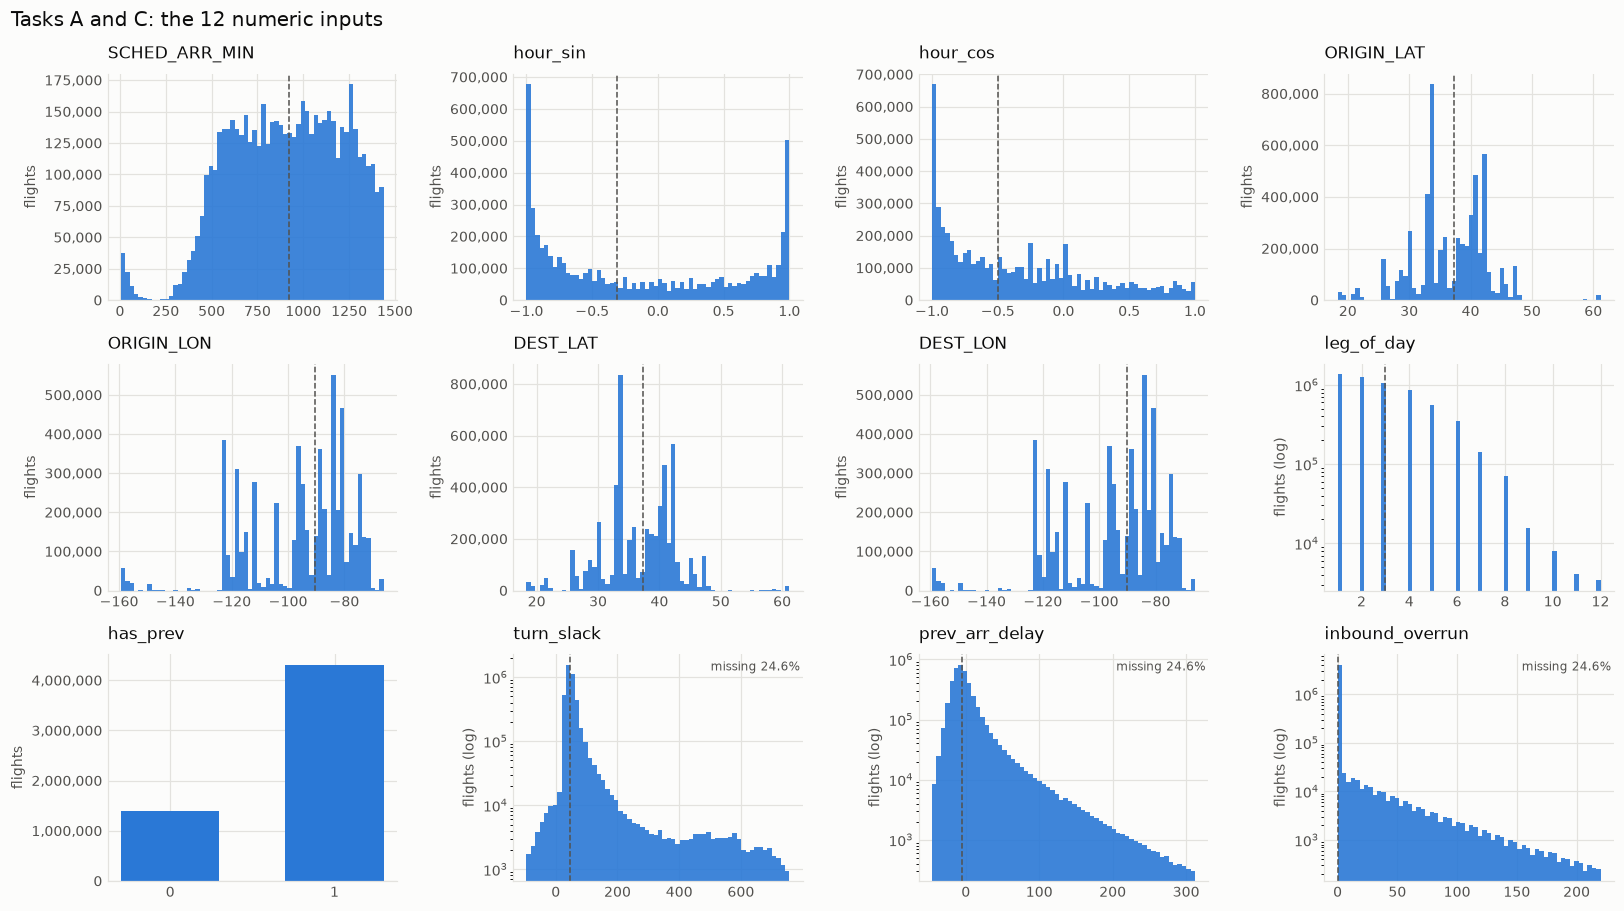

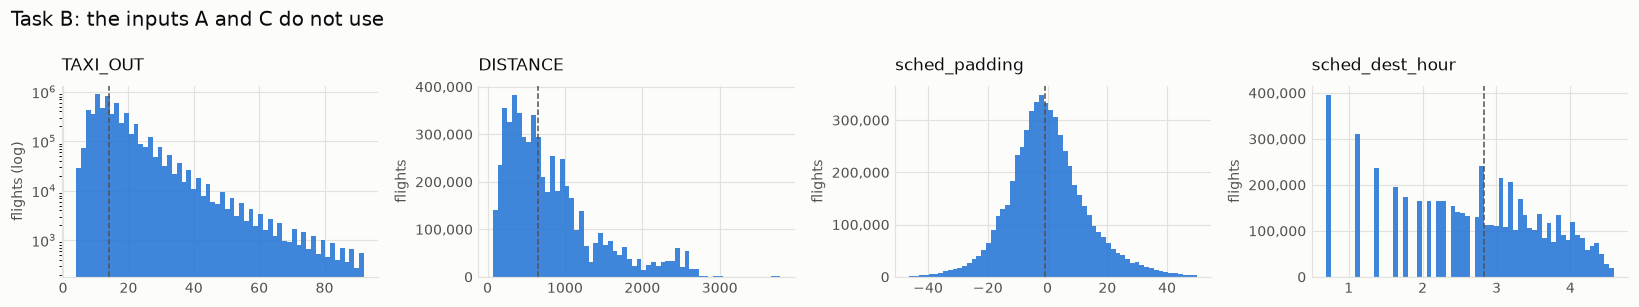

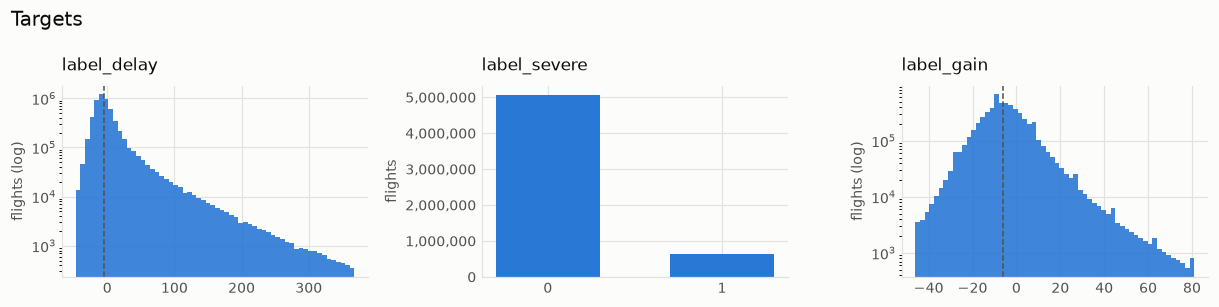

In [11]:
LOGY = {"turn_slack", "prev_arr_delay", "inbound_overrun", "TAXI_OUT", "sched_mph", "leg_of_day",
        "label_delay", "label_gain"}

def grid(cols, title):
    n = len(cols); ncol = 4; nrow = -(-n // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.8 * nrow))
    for ax, c in zip(axes.flat, cols):
        v = d[c].dropna().astype(float)
        lo, hi = v.quantile(0.001), v.quantile(0.999)
        if c in ("has_prev", "label_severe"):
            ax.bar([0, 1], [(v == 0).sum(), (v == 1).sum()], color=BLUE, width=0.6); ax.set_xticks([0, 1])
        else:
            ax.hist(v[(v >= lo) & (v <= hi)], bins=60, color=BLUE, alpha=0.9)
            ax.axvline(v.median(), color=INK_2, linestyle="--", linewidth=1)
        if c in LOGY:
            ax.set_yscale("log")
        miss = d[c].isna().mean()
        _style(ax, "", "flights" + (" (log)" if c in LOGY else ""), c)
        note = f"missing {miss:.1%}" if miss > 0.01 else ""
        if note:
            ax.text(0.99, 0.97, note, transform=ax.transAxes, ha="right", va="top", fontsize=8, color=INK_2)
        if c not in LOGY:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    for ax in list(axes.flat)[n:]:
        ax.set_visible(False)
    fig.suptitle(title, x=0.01, ha="left", color=INK, fontsize=13)
    fig.tight_layout(); plt.show()

grid(["SCHED_ARR_MIN", "hour_sin", "hour_cos", "ORIGIN_LAT", "ORIGIN_LON", "DEST_LAT", "DEST_LON",
      "leg_of_day", "has_prev", "turn_slack", "prev_arr_delay", "inbound_overrun"],
     "Tasks A and C: the 12 numeric inputs")
grid(["TAXI_OUT", "DISTANCE", "sched_padding", "sched_dest_hour"],
     "Task B: the inputs A and C do not use")
grid(["label_delay", "label_severe", "label_gain"], "Targets")

`turn_slack` and the two inbound columns are missing on the first leg of each aircraft's day
(no inbound leg), which is why `has_prev` exists.

### 5.2 Why task B leaves `DEPARTURE_DELAY` out

The gain against `TAXI_OUT` moves as a whole band; against `DEPARTURE_DELAY` the median stays
flat and only the spread widens. A model that predicts one number cannot use a column that only
changes the spread. Removing it ties (LinearRegression R² 0.4743 against 0.4745), and it still
enters the arrival prediction as `DEPARTURE_DELAY + predicted gain`.

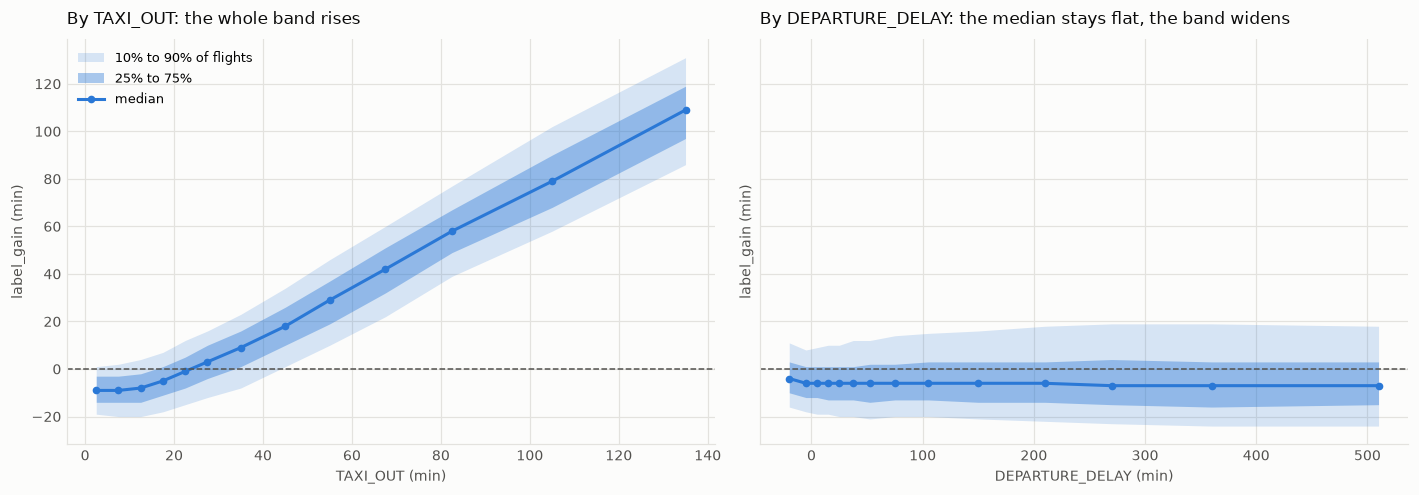

In [12]:
def fan(ax, x, y, edges, xlabel, title, min_n=300):
    grp = y.groupby(pd.cut(x, edges), observed=True)
    q = grp.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).unstack()
    q = q[grp.size() >= min_n]
    mids = [(iv.left + iv.right) / 2 for iv in q.index]
    ax.fill_between(mids, q[0.1], q[0.9], color=BLUE, alpha=0.18, linewidth=0, label="10% to 90% of flights")
    ax.fill_between(mids, q[0.25], q[0.75], color=BLUE, alpha=0.40, linewidth=0, label="25% to 75%")
    ax.plot(mids, q[0.5], color=BLUE, linewidth=2, marker="o", markersize=4, label="median")
    ax.axhline(0, color=INK_2, linewidth=1, linestyle="--")
    _style(ax, xlabel, "label_gain (min)", title)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
fan(axes[0], d["TAXI_OUT"], d["label_gain"], [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90, 120, 150, 180],
    "TAXI_OUT (min)", "By TAXI_OUT: the whole band rises")
fan(axes[1], d["DEPARTURE_DELAY"], d["label_gain"], [-30, -10, 0, 10, 20, 30, 45, 60, 90, 120, 180, 240, 300, 420, 600],
    "DEPARTURE_DELAY (min)", "By DEPARTURE_DELAY: the median stays flat, the band widens")
axes[0].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.tight_layout(); plt.show()

## 6. Model metrics

Full data, scored on the 72 **validation** days (1.12 million flights), with models trained on
the other 293 days (the 72 holdout days were then still part of training). These days were
also used to choose the features, the caps and the winning model, so the numbers can be
slightly optimistic; the final figures come from one run scored on the untouched holdout
days. Every table includes the baselines
logged in the same run:

- **training mean**: predicts the average delay of the training days for every flight;
- **one-column rule**: uses `prev_arr_delay` alone (the inbound aircraft's delay);
- **all-negative**: predicts "not late" for every flight (AUC 0.5; its AUC-PR equals the share of late flights);
- **physics reference** (task B): `TAXI_OUT` as observed, plus air time and taxi-in at their training
  average for the route, month and hour, minus the scheduled time.

Regression is read on MAE first (minutes, cannot be flattered). For classification, *top 10%*
means flagging the 10% of flights the model ranks as most likely late: *caught* is the share of
late flights among them over all late flights, *right* is the share of flags that were late.
`nopca` / `pca` are the two arms of each model.

In [13]:
BENCH = os.path.join(REPO, "docs", "benchmarks")
MODELS = {"A": ["linear_regression", "glm_gaussian_identity", "random_forest_regressor", "gbt_regressor"],
          "C": ["linear_svc", "random_forest_classifier", "gbt_classifier"],
          "B": ["linear_regression", "glm_gaussian_identity", "random_forest_regressor", "gbt_regressor"]}
SOURCES = {"A": [("flight-delay-final-a", "final run, 30 September to 1 October"), ("flight-delay-v3", "tournament of 29 September")],
           "C": [("flight-delay-final-c", "final run, 30 September to 1 October"), ("flight-delay-v3", "tournament of 29 September")],
           "B": [("flight-delay-final-b-pad", "final run, 1 October")]}
TASK_OF = {"A": "regression", "C": "classification", "B": "regression"}

def load(task):
    for folder, label in SOURCES[task]:
        f = os.path.join(BENCH, folder, "tournament_results.json")
        if not os.path.exists(f):
            continue
        r = json.load(open(f))
        want = [f"{m}__{arm}" for m in MODELS[task] for arm in ("nopca", "pca")]
        if all(k in r for k in want):
            return {k: v for k, v in r.items() if v.get("task") == TASK_OF[task]}, label
    raise FileNotFoundError(task)

NAMES = {"baseline_regression": "training mean", "baseline_classification": "all-negative",
         "rule_prev_arr_delay_regression": "one-column rule", "rule_prev_arr_delay_classification": "one-column rule",
         "physics_reference": "physics reference", "linear_regression": "LinearRegression",
         "glm_gaussian_identity": "GLM (Gaussian)", "random_forest_regressor": "RandomForest",
         "gbt_regressor": "GBT", "linear_svc": "LinearSVC", "random_forest_classifier": "RandomForest",
         "gbt_classifier": "GBT"}

def table(task, cols, sort):
    r, label = load(task)
    rows = []
    for k, v in r.items():
        is_base = v["arm"] == "none"
        rows.append({"model": NAMES.get(v["model"], v["model"]), "arm": "" if is_base else v["arm"],
                     "kind": "baseline" if is_base else "model", **{c: v.get(c, np.nan) for c in cols}})
    t = pd.DataFrame(rows).sort_values(["kind", sort], ascending=[True, sort in ("mae", "rmse")])
    t = t.set_index(["kind", "model", "arm"]).dropna(axis=1, how="all")
    return t, label

REG = {"mae": "MAE", "rmse": "RMSE", "r2": "R²", "r2_arrival": "R² arrival"}
t, label = table("A", list(REG), "mae")
display(Markdown(f"**Task A**, regression before departure ({label})"))
display(t.rename(columns=REG).style.format("{:.3f}", na_rep=""))

**Task A**, regression before departure (final run, 30 September to 1 October)

In [14]:
CLF = {"areaUnderROC": "AUC", "areaUnderPR": "AUC-PR", "recall_at_10pct": "top 10%: caught",
       "precision_at_10pct": "top 10%: right", "precision_late": "precision (late)", "recall_late": "recall (late)"}
t, label = table("C", list(CLF), "areaUnderPR")
display(Markdown(f"**Task C**, classification before departure ({label})"))
display(t.rename(columns=CLF).style.format("{:.3f}", na_rep=""))

**Task C**, classification before departure (final run, 30 September to 1 October)

In [15]:
t, label = table("B", list(REG), "mae")
display(Markdown(f"**Task B**, the gain after take-off ({label}). *R² arrival* adds `DEPARTURE_DELAY` "
                 "back and scores the arrival delay."))
display(t.rename(columns=REG).style.format("{:.3f}", na_rep=""))

**Task B**, the gain after take-off (final run, 1 October). *R² arrival* adds `DEPARTURE_DELAY` back and scores the arrival delay.

**Reading.**

- Every task beats its baselines, and the gradient-boosted trees (GBT) are best in all three.
- Before departure the scores are modest (task A R² around 0.37): the weather and the
  day's congestion are not in the data. What the model does know comes mostly from the inbound
  aircraft; with the schedule alone the task C AUC is about 0.68, with the inbound delay about 0.82.
- Task B beats the physics reference by about 0.6 minutes of MAE. Its R² on the gain (around 0.52) is the
  model's own contribution; on the arrival scale the R² is about 0.95, but 0.90 of that comes
  for free from `DEPARTURE_DELAY` plus the average gain (the training-mean row). The MAE is the
  same number on both scales.
- For the linear models the PCA and no-PCA arms are within noise of each other; for the trees
  the no-PCA arm is clearly better. With 12 numeric columns there is little to compress.

### 6.1 Training curves

How the chosen models got to their scores. MLlib models have no epochs, so each family
shows what it actually iterates over:

- **GBT**: the loss after each boosting iteration (each new tree), on a 10% sample of the
  training days and on the validation days, from `evaluateEachIteration` on the logged model.
  Regression: RMSE in minutes. Classification: Spark's log loss, weighted by class as in training.
- **LinearRegression / LinearSVC**: the training objective after each optimizer step
  (`objectiveHistory`). A LinearRegression without L1 penalty is solved in closed form (normal
  equation), so it has no curve.
- **RandomForest** grows its trees independently, so there is no iteration curve to draw.

The curves are computed after the fact by `scripts/training_curves.py` and logged into each
model's MLflow run as stepped metrics. They were not used to choose anything: the number of
trees came from cross-validation on the training days.

,GBT loss,"train, first tree","train, last","validation, first tree","validation, last",lowest validation at,linear model
task,,,,,,,
A,RMSE (min),31.247,30.163,34.297,33.396,150 of 150,"LinearRegression: 42 steps, OWL-QN / L-BFGS"
C,log loss (weighted),1.012,0.897,1.020,0.911,149 of 150,"LinearSVC: 30 steps, OWL-QN / L-BFGS"
B,RMSE (min),10.006,8.744,10.362,9.237,150 of 150,"LinearRegression: 0 steps, normal equation (closed form)"


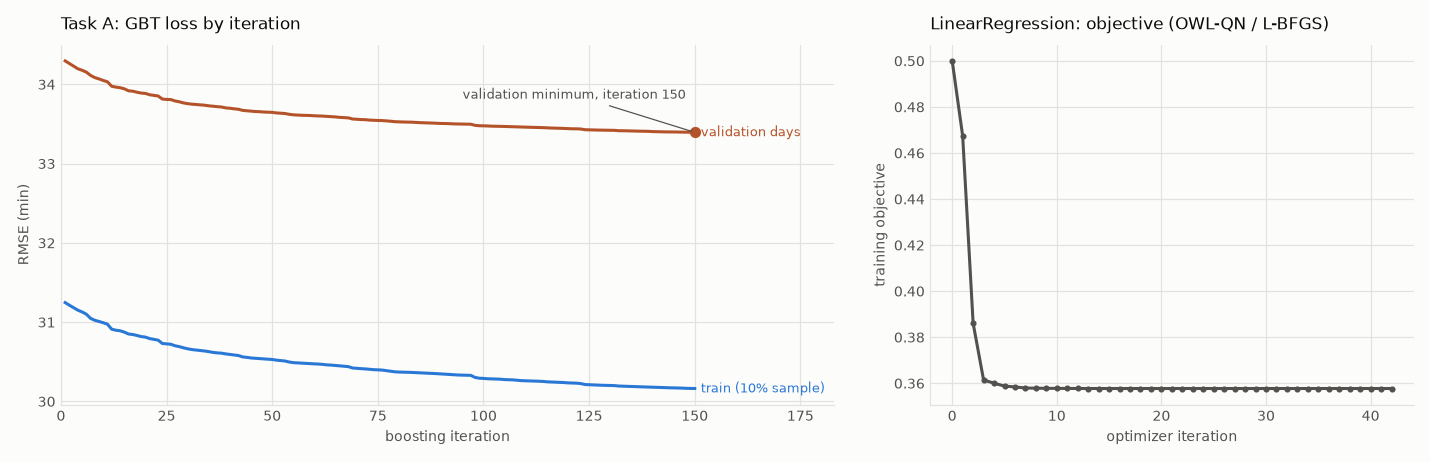

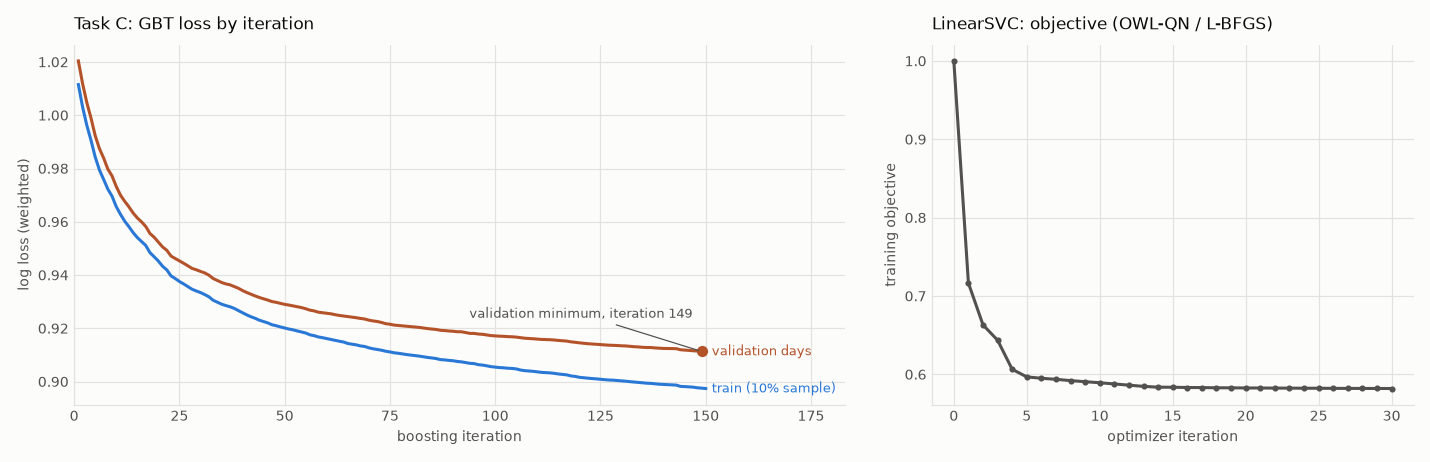

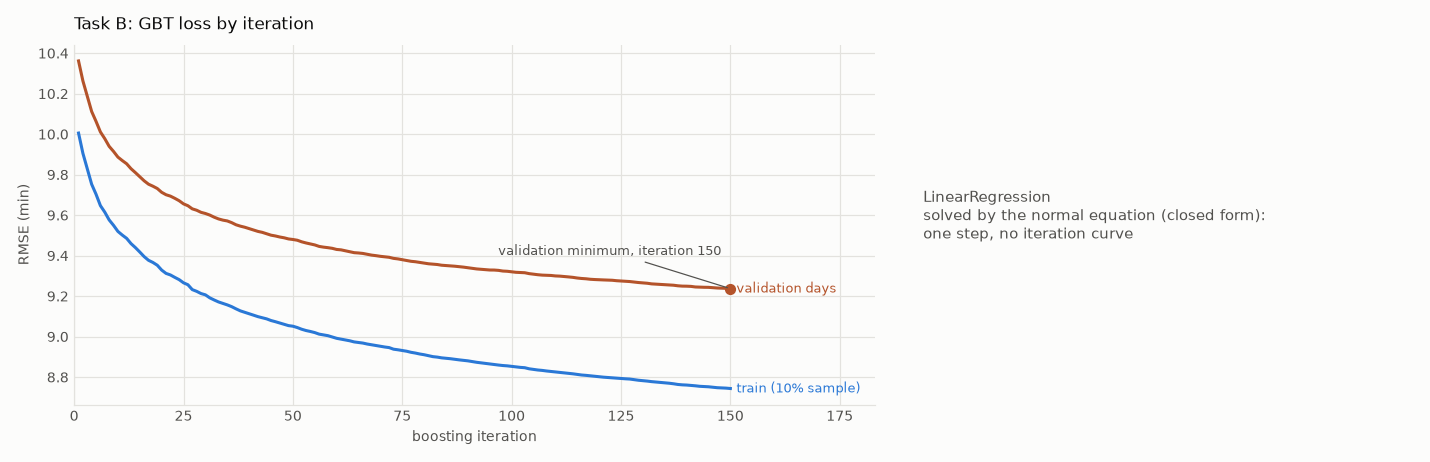

In [16]:
from IPython.display import Image
rows = []
for task, exp in [("A", "flight-delay-final-a"), ("C", "flight-delay-final-c"), ("B", "flight-delay-final-b-pad")]:
    j = json.load(open(os.path.join(BENCH, exp, "training_curves.json")))
    g, lin = j["gbt"], j["linear"]
    rows.append({"task": task, "GBT loss": g["metric"], "train, first tree": g["train"][0],
                 "train, last": g["train"][-1], "validation, first tree": g["validation"][0],
                 "validation, last": g["validation"][-1],
                 "lowest validation at": f"{g['best_iteration']} of {g['iterations']}",
                 "linear model": f"{lin['model']}: {lin['iterations']} steps, {lin['solver']}"})
display(pd.DataFrame(rows).set_index("task").style.format(precision=3))
for exp in ["flight-delay-final-a", "flight-delay-final-c", "flight-delay-final-b-pad"]:
    display(Image(filename=os.path.join(BENCH, exp, "training_curves.png")))

**Reading.**

- In all three tasks the GBT validation loss is still falling at the last tree (lowest at
  iteration 150, 149 and 150 of 150), and the train and validation curves stay parallel: no
  sign of overfitting, and a few more trees might still help a little. 150 was the largest
  tree count in the search.
- The constant gap between the curves is the difference between days, not memorisation: the
  validation days have their own weather and congestion, which no feature describes.
- LinearRegression (task A, elastic net) reaches its minimum within about 6 steps and stops at
  42 on the tolerance. LinearSVC (task C) runs to its 30-step cap, but its objective is flat
  from about step 15, so the cap is not cutting it short. Task B's LinearRegression has no
  L1 term and is solved in one step.